# DTLZ1 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz1_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1280
NGEN = 500
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz1_segura = partial(benchmarks.dtlz1, obj=NOBJ)
toolbox = build_toolbox(func_dtlz1_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz1_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 1.0, 1.0, 0.0, 0.400026210656679, 0.5005683196952968, 0.6005698949878746, 0.49901937871866964, 0.49997329129906726]
[1.0, 1.0, 1.0, 0.0, 0.400026210656679, 0.5005683196952968, 0.6005698949878746, 0.49901937871866964, 0.49997329129906726]
[1.0, 1.0, 1.0, 1.0, 0.5000022568849025, 0.4999991723838994, 0.5997536321376525, 0.497859291794604, 0.5000894334453136]
[1.0, 1.0, 1.0, 1.0, 0.5000022568849025, 0.4999991723838994, 0.5997536321376525, 0.497859291794604, 0.5000894334453136]
[0.0, 0.9249790955414835, 0.9979896556119967, 0.9586740784951914, 0.500007262962951, 0.49999856491934713, 0.5999679636069005, 0.49997770812222947, 0.49988301921070194]
[0.0, 0.9249790955414835, 0.9979896556119967, 0.9586740784951914, 0.500007262962951, 0.49999856491934713, 0.5999679636069005, 0.49997770812222947, 0.49988301921070194]
[1.0, 0.0, 0.04188132517058181, 0.02432940586641853, 0.39999622414855196, 0.5004527311585596, 0.5999802299478799, 0.3990937382243248, 0.5000943872614387]
[1.0, 1.0, 0.0, 0.64653495

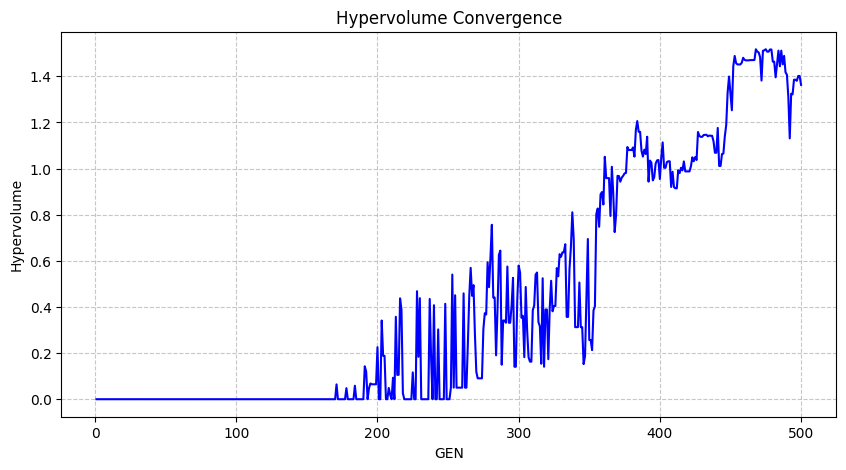

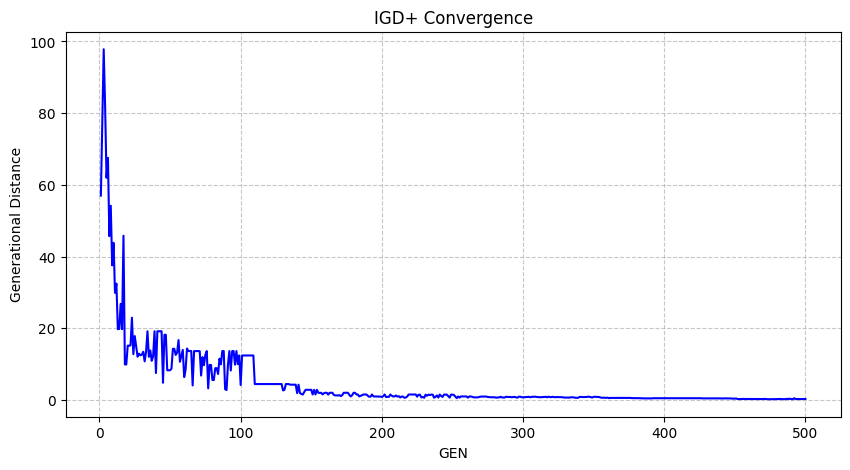

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()